In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fertility.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())

Shape: (100, 10)

First 5 rows:
   season   age  childish-disease  trauma  surgical-intervention  fevers  \
0   -0.33  0.69                 0       1                      1       0   
1   -0.33  0.94                 1       0                      1       0   
2   -0.33  0.50                 1       0                      0       0   
3   -0.33  0.75                 0       1                      1       0   
4   -0.33  0.67                 1       1                      0       0   

   alcoholic  smoking  sitting output  
0        0.8        0     0.88      N  
1        0.8        1     0.31      O  
2        1.0       -1     0.50      N  
3        1.0       -1     0.38      N  
4        0.8       -1     0.50      O  


Class Distribution:
output
N    88
O    12
Name: count, dtype: int64


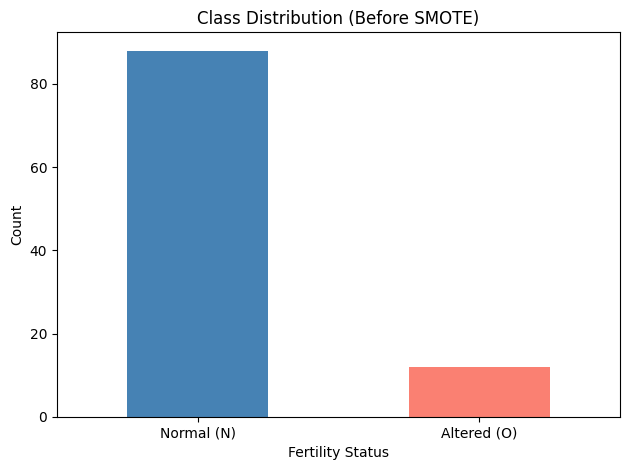

In [3]:
print('Class Distribution:')
print(df['output'].value_counts())

# Plot class distribution (before SMOTE)
df['output'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution (Before SMOTE)')
plt.xlabel('Fertility Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Normal (N)', 'Altered (O)'], rotation=0)
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Check missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
season                   0
age                      0
childish-disease         0
trauma                   0
surgical-intervention    0
fevers                   0
alcoholic                0
smoking                  0
sitting                  0
output                   0
dtype: int64


In [5]:
# Encode target: N -> 0, O -> 1
le = LabelEncoder()
df['output'] = le.fit_transform(df['output'])

# Features and target
X = df.drop('output', axis=1)
y = df['output']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (80, 9)
Test set size: (20, 9)


In [6]:
from imblearn.over_sampling import SMOTE

print('Class distribution before SMOTE:', dict(pd.Series(y_train).value_counts()))

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Class distribution after SMOTE:', dict(pd.Series(y_train_res).value_counts()))

Class distribution before SMOTE: {0: np.int64(70), 1: np.int64(10)}
Class distribution after SMOTE: {0: np.int64(70), 1: np.int64(70)}


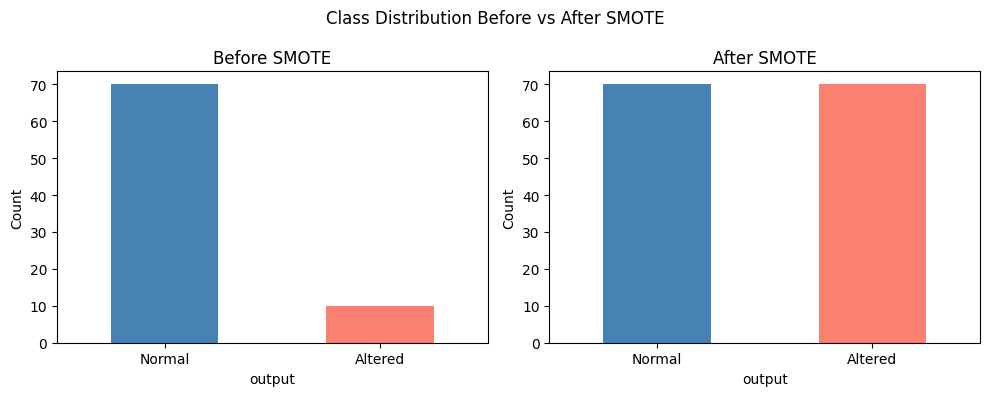

In [7]:
# Plot before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(['Normal', 'Altered'], rotation=0)
axes[0].set_ylabel('Count')

pd.Series(y_train_res).value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(['Normal', 'Altered'], rotation=0)
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before vs After SMOTE')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_res, y_train_res)

print('Logistic Regression model trained successfully.')
print('Training Accuracy:', model.score(X_train_res, y_train_res))

Logistic Regression model trained successfully.
Training Accuracy: 0.7928571428571428
